In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler



In [2]:
df = pd.read_csv('/content/student-mat.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [4]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


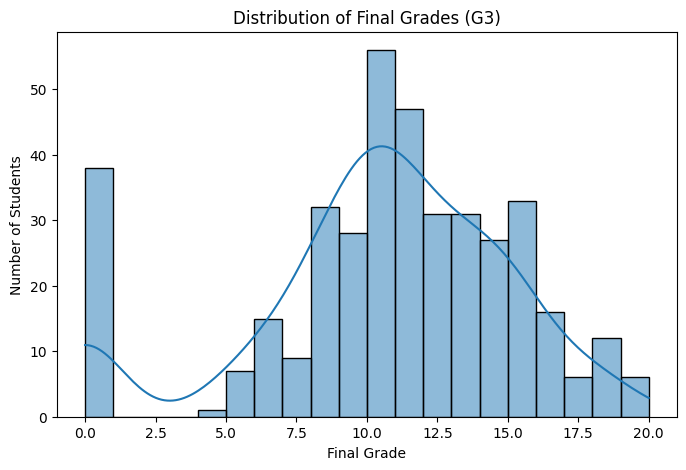

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20, kde=True)

plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

Converting Categorical Columns

In [6]:
label_encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = label_encoder.fit_transform(df[col])

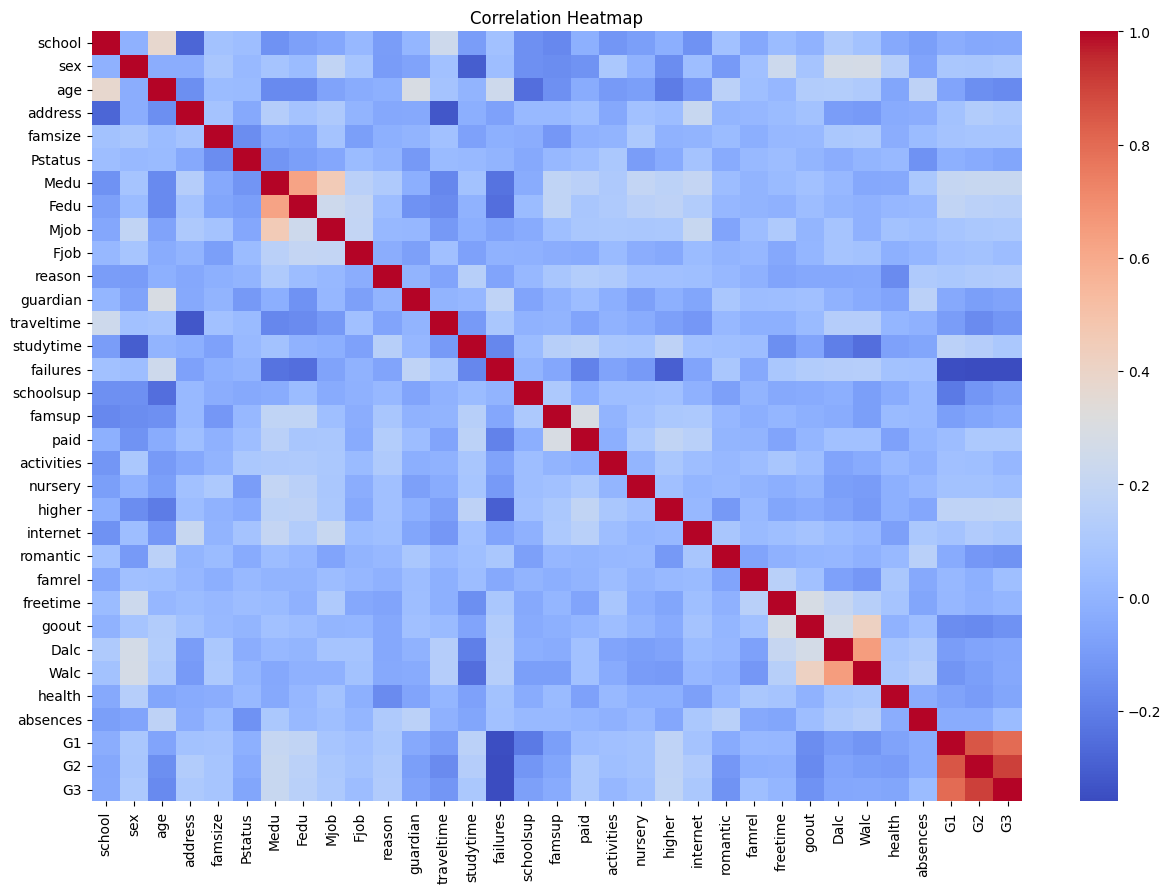

In [7]:
plt.figure(figsize=(15,10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

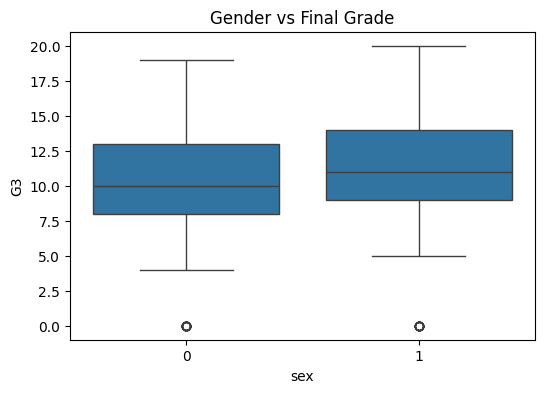

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='G3', data=df)
plt.title("Gender vs Final Grade")
plt.show()

Gender does not appear to have a significant impact on final grades. Although students in category sex = 1 have a slightly higher median score, the substantial overlap between the distributions suggests that gender is not a strong predictor of academic performance.

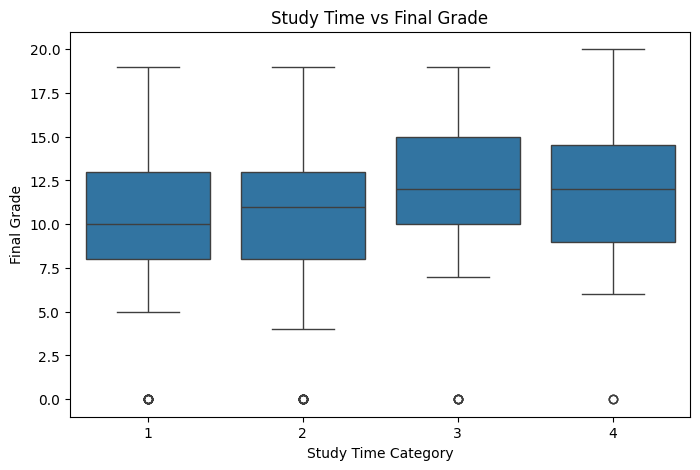

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='studytime', y='G3', data=df)
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade")
plt.show()

A positive relationship exists between study time and academic performance. Students who dedicate more time to studying generally achieve higher final grades, indicating that study habits play an important role in student success.

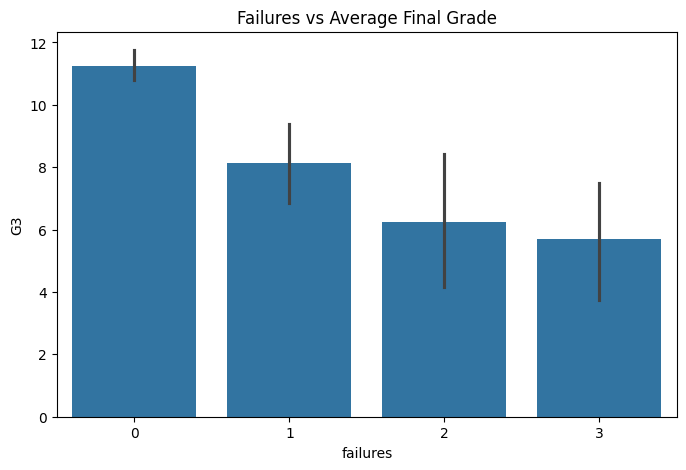

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(x='failures', y='G3', data=df)
plt.title("Failures vs Average Final Grade")
plt.show()

Previous academic failures have a strong negative impact on final grades. Students with no prior failures achieve the highest average scores, while students with multiple failures perform considerably worse.

Boxplot analysis revealed a small number of extreme grade values, particularly students with a final grade of 0. These values represent genuine student outcomes rather than erroneous data and were therefore retained in the dataset.

In [11]:
X = df.drop('G3', axis=1)
y = df['G3']
print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (395, 32)
Target Shape: (395,)


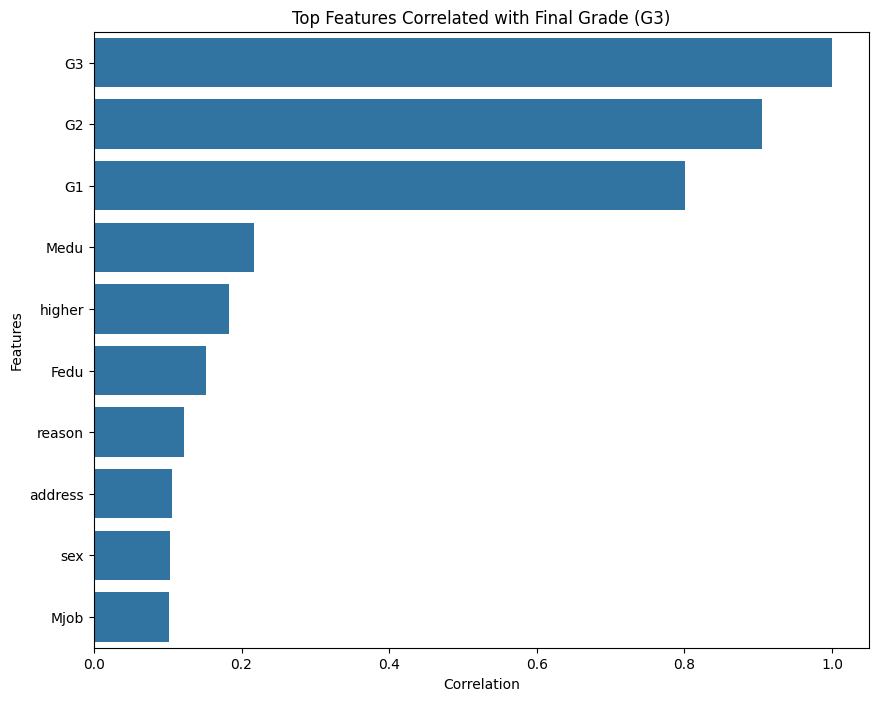

In [12]:
plt.figure(figsize=(10,8))

top_corr = df.corr()['G3'].sort_values(ascending=False)

sns.barplot(x=top_corr.values[:10], y=top_corr.index[:10])

plt.title("Top Features Correlated with Final Grade (G3)")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 316
Testing Samples: 79


In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(64,activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,593 (57.00 KB)

 Trainable params: 14,593 (57.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [18]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_split=0.20, verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 129.1300 - mae: 10.3551 - val_loss: 117.3152 - val_mae: 10.0895
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 110.9190 - mae: 9.6215 - val_loss: 100.3778 - val_mae: 9.3175
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 92.7748 - mae: 8.8209 - val_loss: 79.5025 - val_mae: 8.2603
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 71.2265 - mae: 7.7018 - val_loss: 55.0911 - val_mae: 6.7648
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 46.0738 - mae: 6.0976 - val_loss: 31.4751 - val_mae: 4.8831
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 23.1272 - mae: 4.1260 - val_loss: 16.6290 - val_mae: 3.1996
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 14.7073 - mae: 2.8862 - val_loss: 15.2908 - val_mae: 2.6504
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 12.8109 - mae: 2.5758 - val_loss: 11.8630 - val_mae: 2.2905
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9

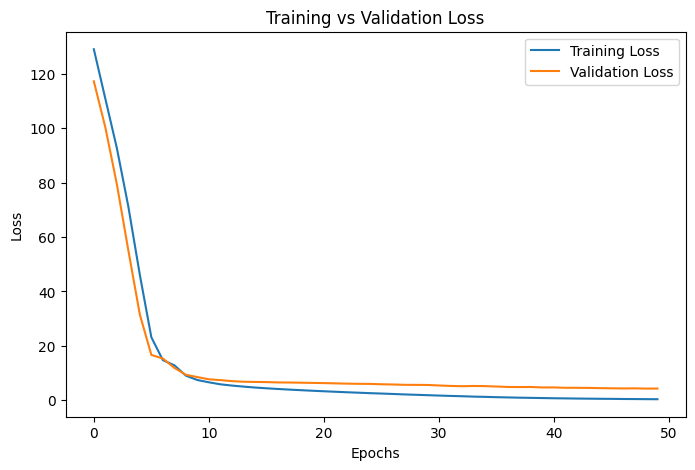

In [19]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

The graph shows how the model's error changed during training. Both training and validation loss decreased significantly in the early epochs, indicating that the model learned useful patterns from the data. The validation loss stabilized without increasing, which suggests that the model generalizes well to unseen data. A small gap between training and validation loss indicates minor overfitting, but overall the model performs well.

In [20]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("\nTest Loss (MSE):", loss)
print("Test MAE:", mae)


Test Loss (MSE): 7.627639293670654
Test MAE: 1.9089956283569336


In [21]:
predictions = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [22]:
print("\nSample Predictions\n")

for i in range(10):

    print("Actual Grade    :", y_test.iloc[i])
    print("Predicted Grade :", round(predictions[i][0], 2))
    print("-" * 40)


Sample Predictions

Actual Grade    : 10
Predicted Grade : 7.23
----------------------------------------
Actual Grade    : 12
Predicted Grade : 11.94
----------------------------------------
Actual Grade    : 5
Predicted Grade : 3.77
----------------------------------------
Actual Grade    : 10
Predicted Grade : 8.68
----------------------------------------
Actual Grade    : 9
Predicted Grade : 13.08
----------------------------------------
Actual Grade    : 13
Predicted Grade : 11.45
----------------------------------------
Actual Grade    : 18
Predicted Grade : 18.98
----------------------------------------
Actual Grade    : 6
Predicted Grade : 8.76
----------------------------------------
Actual Grade    : 0
Predicted Grade : 6.3
----------------------------------------
Actual Grade    : 14
Predicted Grade : 11.48
----------------------------------------


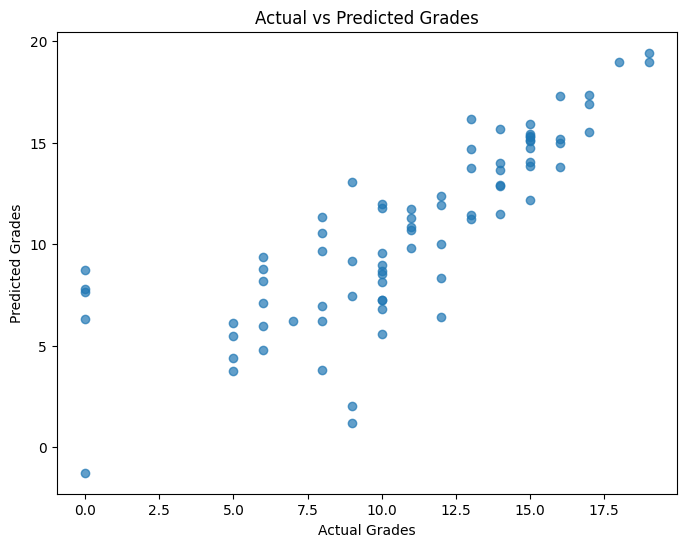

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.7)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted Grades")
plt.show()

The Actual vs Predicted Grades scatter plot demonstrates a positive correlation between actual and predicted student grades. Most points follow an upward trend, indicating that the MLP model successfully captures the relationship between student attributes and academic performance. While some prediction errors are present, particularly for very low and very high grades, the overall distribution suggests that the model provides reasonably accurate predictions and generalizes well to unseen data.

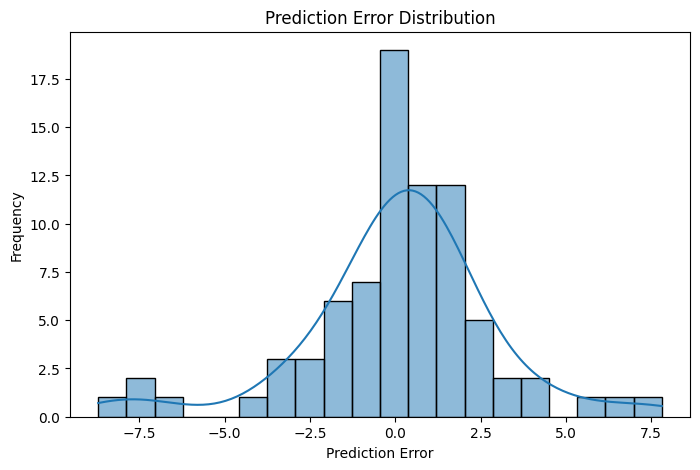

In [24]:
errors = y_test - predictions.flatten()

plt.figure(figsize=(8,5))

sns.histplot(errors, bins=20, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

In [25]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test).flatten()
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
R² Score: 0.6280117034912109
